# Underwater Garbage Detection — Day 2: Dataset Exploration

**Dataset**: TrashCAN<br>
**Project:** Underwater Garbage Detection<br>

## 1. Mount Drive & Extract Dataset

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive/INTERNSHIPWORK/')

['dataset', 'dataset.zip', 'UnderWater_Garbage_Day2 work .ipynb']

In [3]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/INTERNSHIPWORK/dataset.zip'
extract_path = '/content/TrashCAN'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


## 2. Explore Folder Structure

In [4]:
import os

for root, dirs, files in os.walk('/content/TrashCAN'):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 50)

/content/TrashCAN
Folders: ['dataset']
Files: []
--------------------------------------------------
/content/TrashCAN/dataset
Folders: ['scripts', 'instance_version', 'original_data', 'material_version']
Files: ['README.txt']
--------------------------------------------------
/content/TrashCAN/dataset/scripts
Folders: []
Files: ['trash_can_coco.py']
--------------------------------------------------
/content/TrashCAN/dataset/instance_version
Folders: ['val', 'train']
Files: ['README.txt', 'instances_train_trashcan.json', 'instances_val_trashcan.json']
--------------------------------------------------
/content/TrashCAN/dataset/instance_version/val
Folders: []
Files: ['vid_000154_frame0000011.jpg', 'vid_000112_frame0000018.jpg', 'vid_000002_frame0000021.jpg', 'vid_000038_frame0000020.jpg', 'vid_000142_frame0000113.jpg']
--------------------------------------------------
/content/TrashCAN/dataset/instance_version/train
Folders: []
Files: ['vid_000076_frame0000026.jpg', 'vid_000253_frame0

In [5]:
dataset_path = '/content/TrashCAN/dataset'
material_path = os.path.join(dataset_path, 'material_version')

print("Material version contents:")
for item in os.listdir(material_path):
    print(item)

Material version contents:
README.txt
instances_train_trashcan.json
val
train
instances_val_trashcan.json


## 3. Count Train/Val Images

In [6]:
train_path = os.path.join(material_path, 'train')
val_path = os.path.join(material_path, 'val')

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

train_images = [
    f for f in os.listdir(train_path)
    if f.lower().endswith(image_extensions)
]

val_images = [
    f for f in os.listdir(val_path)
    if f.lower().endswith(image_extensions)
]

print("===== DATASET IMAGE COUNT =====")
print("Training images   :", len(train_images))
print("Validation images :", len(val_images))
print("Total images      :", len(train_images) + len(val_images))

===== DATASET IMAGE COUNT =====
Training images   : 6008
Validation images : 1204
Total images      : 7212


## 4. Load COCO Annotations & Verify

In [7]:
import json

train_json_path = os.path.join(material_path, 'instances_train_trashcan.json')
val_json_path = os.path.join(material_path, 'instances_val_trashcan.json')

with open(train_json_path, 'r') as f:
    train_data = json.load(f)

with open(val_json_path, 'r') as f:
    val_data = json.load(f)

print("===== COCO DATASET INFORMATION =====")
print("\nTRAINING")
print("Images       :", len(train_data['images']))
print("Annotations  :", len(train_data['annotations']))
print("Categories   :", len(train_data['categories']))

print("\nVALIDATION")
print("Images       :", len(val_data['images']))
print("Annotations  :", len(val_data['annotations']))
print("Categories   :", len(val_data['categories']))

===== COCO DATASET INFORMATION =====

TRAINING
Images       : 6008
Annotations  : 9741
Categories   : 16

VALIDATION
Images       : 1204
Annotations  : 2595
Categories   : 16


### 4a. Verify JSON integrity — missing annotations / orphan references
Checks that every annotation points to a real image, and flags images that have zero annotations.

In [8]:
image_ids_in_json = {img['id'] for img in train_data['images']}
annotated_ids = {ann['image_id'] for ann in train_data['annotations']}

images_without_annotations = image_ids_in_json - annotated_ids
orphan_annotations = annotated_ids - image_ids_in_json

print("Images with zero annotations:", len(images_without_annotations))
print("Annotations pointing to missing images:", len(orphan_annotations))

if images_without_annotations:
    sample_missing = list(images_without_annotations)[:10]
    id_to_filename = {img['id']: img['file_name'] for img in train_data['images']}
    print("\nSample images with no annotations:")
    for img_id in sample_missing:
        print(" -", id_to_filename[img_id])

Images with zero annotations: 0
Annotations pointing to missing images: 0


## 5. Classes — All 16 Categories

In [9]:
categories = train_data['categories']

for cat in categories:
    print(cat['id'], "→", cat['name'])

1 → rov
2 → plant
3 → animal_fish
4 → animal_starfish
5 → animal_shells
6 → animal_crab
7 → animal_eel
8 → animal_etc
9 → trash_etc
10 → trash_fabric
11 → trash_fishing_gear
12 → trash_metal
13 → trash_paper
14 → trash_plastic
15 → trash_rubber
16 → trash_wood


### 5a. Identify garbage vs non-garbage classes
The TrashCAN dataset mixes ROV, marine life, and plant categories in with the actual trash categories.
Only the `trash_*` classes are garbage — the rest (`rov`, `plant`, `animal_*`) are not.

In [10]:
category_names = {cat['id']: cat['name'] for cat in categories}

garbage_classes = [c['name'] for c in categories if c['name'].startswith('trash_')]
non_garbage_classes = [c['name'] for c in categories if not c['name'].startswith('trash_')]

print("Garbage classes (", len(garbage_classes), "):", garbage_classes)
print("Non-garbage classes (", len(non_garbage_classes), "):", non_garbage_classes)

Garbage classes ( 8 ): ['trash_etc', 'trash_fabric', 'trash_fishing_gear', 'trash_metal', 'trash_paper', 'trash_plastic', 'trash_rubber', 'trash_wood']
Non-garbage classes ( 8 ): ['rov', 'plant', 'animal_fish', 'animal_starfish', 'animal_shells', 'animal_crab', 'animal_eel', 'animal_etc']


## 6. Class Distribution

In [11]:
from collections import Counter

counts = Counter(ann['category_id'] for ann in train_data['annotations'])

print("Class distribution (all 16 classes):\n")
for category_id, count in counts.most_common():
    print(category_names[category_id], "→", count)

Class distribution (all 16 classes):

rov → 2653
trash_etc → 1630
trash_plastic → 1490
trash_metal → 901
animal_fish → 611
plant → 405
animal_starfish → 274
trash_wood → 271
animal_eel → 267
trash_fabric → 247
animal_crab → 247
animal_etc → 180
animal_shells → 171
trash_paper → 154
trash_fishing_gear → 127
trash_rubber → 113


### 6a. Garbage-only class distribution
Same data, filtered to only the garbage (`trash_*`) classes — this is what actually matters for the detection task.

In [12]:
garbage_ids = {c['id'] for c in categories if c['name'].startswith('trash_')}

garbage_counts = Counter(
    ann['category_id'] for ann in train_data['annotations']
    if ann['category_id'] in garbage_ids
)

print("Garbage-only class distribution:\n")
for cid, count in garbage_counts.most_common():
    print(category_names[cid], "→", count)

Garbage-only class distribution:

trash_etc → 1630
trash_plastic → 1490
trash_metal → 901
trash_wood → 271
trash_fabric → 247
trash_paper → 154
trash_fishing_gear → 127
trash_rubber → 113


## 7. Visualize Sample Images

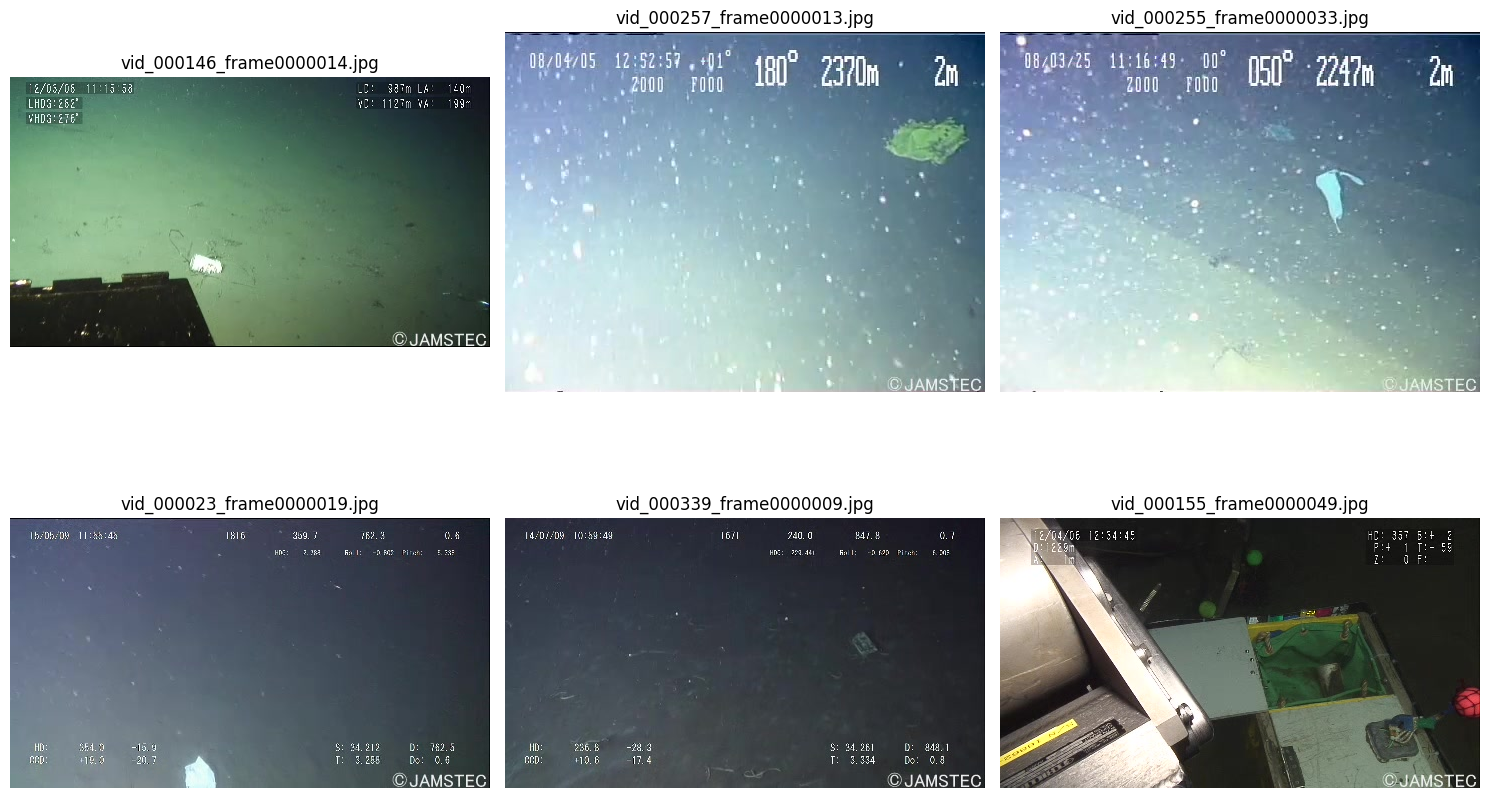

In [13]:
import random
from PIL import Image
import matplotlib.pyplot as plt

train_folder = os.path.join(material_path, 'train')

images = [
    f for f in os.listdir(train_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

sample_images = random.sample(images, min(6, len(images)))

plt.figure(figsize=(15, 10))

for i, filename in enumerate(sample_images):
    img_path = os.path.join(train_folder, filename)
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(filename)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Visualize Annotations / Bounding Boxes
Actually draws the bounding boxes on an image, instead of just printing coordinates.

In [14]:
image_info = train_data['images'][0]
image_id = image_info['id']
file_name = image_info['file_name']

image_annotations = [
    ann for ann in train_data['annotations']
    if ann['image_id'] == image_id
]

print("Image ID:", image_id)
print("File:", file_name)
print("Number of objects:", len(image_annotations))

Image ID: 1
File: vid_000421_frame0000005.jpg
Number of objects: 1


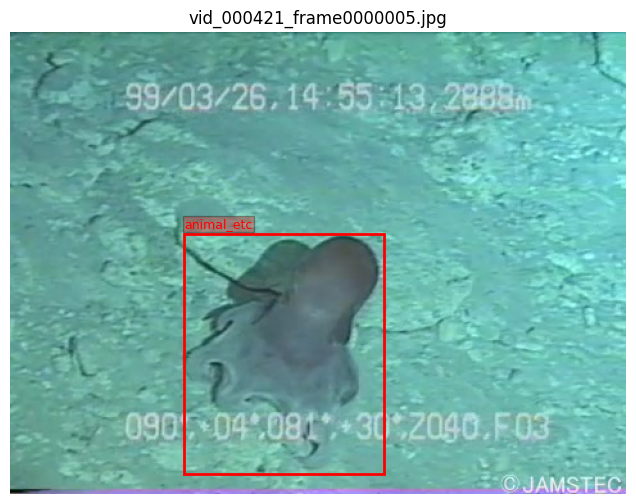

In [15]:
import matplotlib.patches as patches

fig, ax = plt.subplots(1, figsize=(8, 6))
img_path = os.path.join(train_folder, file_name)
img = Image.open(img_path)
ax.imshow(img)

for ann in image_annotations:
    x, y, w, h = ann['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y - 5, category_names[ann['category_id']], color='red', fontsize=9,
            bbox=dict(facecolor='red', alpha=0.3, pad=1))

plt.axis('off')
plt.title(file_name)
plt.show()

## 9. Check Corrupted Images

In [16]:
bad_images = []

for filename in images:
    path = os.path.join(train_folder, filename)
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_images.append(filename)

print("Total images:", len(images))
print("Corrupted images:", len(bad_images))

if bad_images:
    print("Bad files:")
    print(bad_images[:20])

Total images: 6008
Corrupted images: 0


## 10. Check Image Resolutions

In [17]:
resolution_counts = Counter()

for filename in images:
    path = os.path.join(train_folder, filename)
    try:
        with Image.open(path) as img:
            resolution_counts[img.size] += 1
    except Exception:
        pass

print("Most common resolutions:\n")
for resolution, count in resolution_counts.most_common(10):
    print(resolution, "→", count)

Most common resolutions:

(480, 360) → 3008
(480, 270) → 3000


In [18]:
# Compare image files with image entries in the COCO JSON.
# basename() makes the check robust to paths stored inside the JSON.

json_image_names = {
    os.path.basename(img['file_name'])
    for img in train_data['images']
}

actual_image_names = set(train_images)

images_without_json_entry = actual_image_names - json_image_names
json_entries_without_image = json_image_names - actual_image_names

print("===== MISSING / UNMATCHED ANNOTATION CHECK =====")
print("Training image files              :", len(actual_image_names))
print("COCO image entries                :", len(json_image_names))
print("Images without COCO image entry   :", len(images_without_json_entry))
print("JSON entries without image file   :", len(json_entries_without_image))

if images_without_json_entry:
    print("\nImages without COCO entries (first 20):")
    for name in sorted(images_without_json_entry)[:20]:
        print(" -", name)

if json_entries_without_image:
    print("\nJSON entries without image files (first 20):")
    for name in sorted(json_entries_without_image)[:20]:
        print(" -", name)

if not images_without_json_entry and not json_entries_without_image:
    print("All training image files have matching COCO image entries.")


===== MISSING / UNMATCHED ANNOTATION CHECK =====
Training image files              : 6008
COCO image entries                : 6008
Images without COCO image entry   : 0
JSON entries without image file   : 0
All training image files have matching COCO image entries.


# **# DAY-3 Visual EDA**

# 11.Visual EDA setup

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path
import random

# Reuse train_path, train_images, train_data, category_names,
# garbage_classes and annotation_counts from the Day-2 section.

print("Visual EDA setup complete.")
print("Training images available:", len(train_images))


Visual EDA setup complete.
Training images available: 6008


## 12. Representative raw-image grid

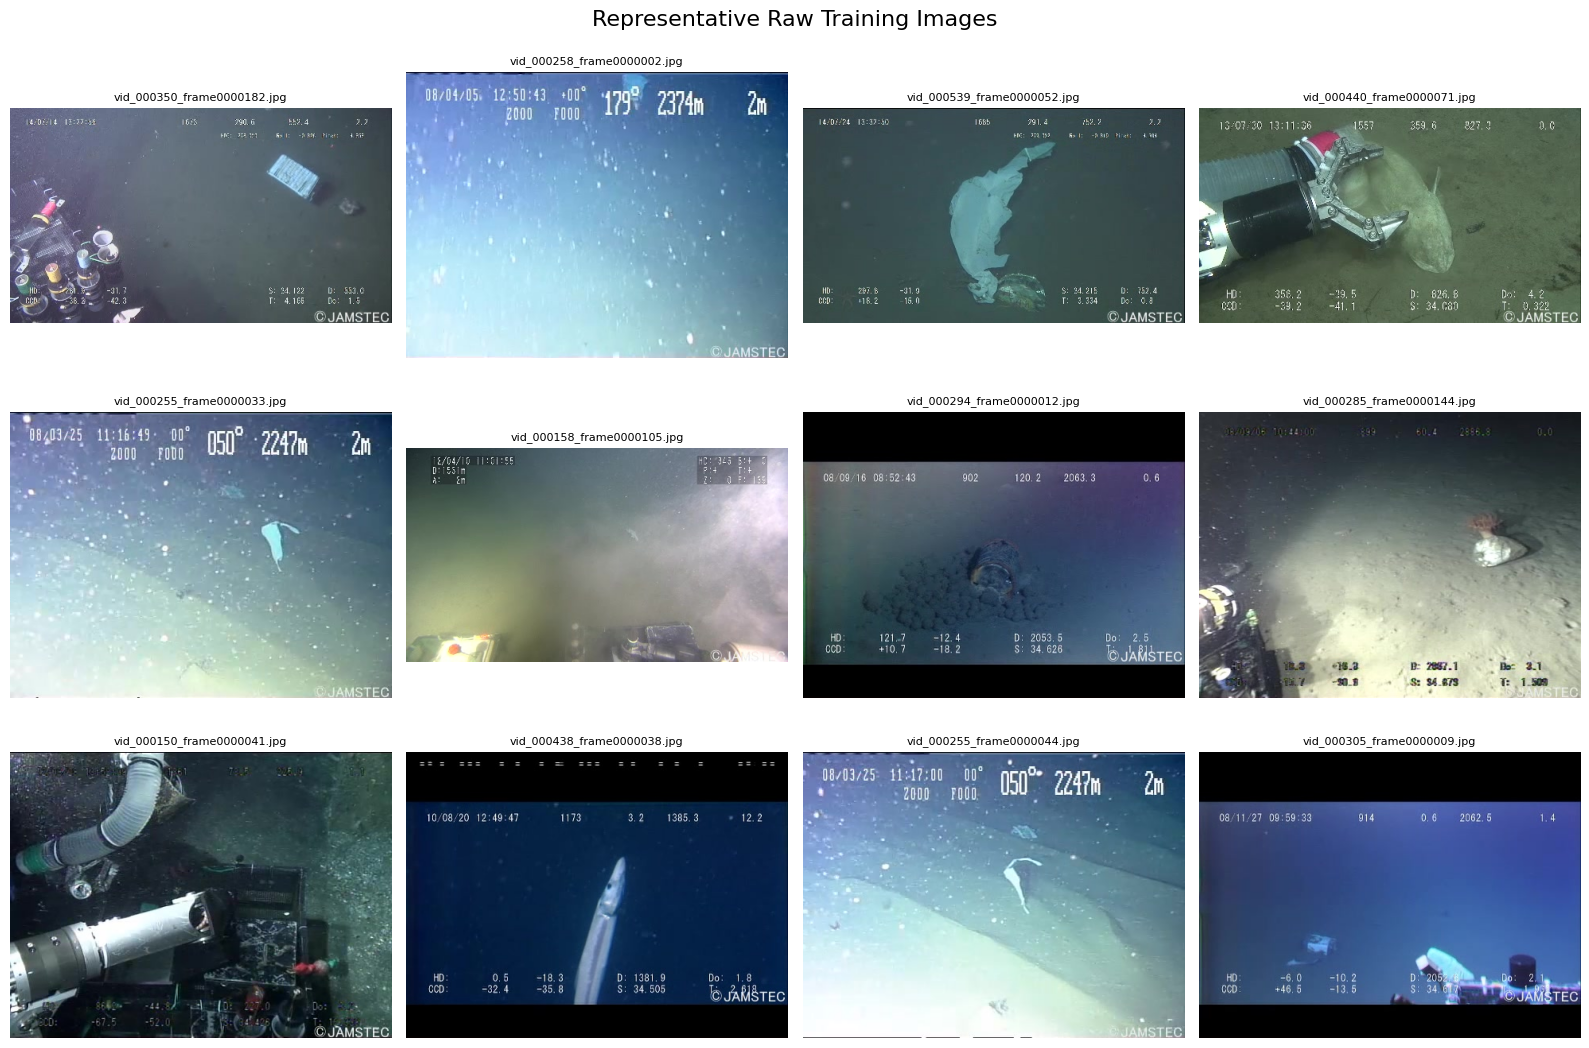

In [20]:
# Show a reproducible set of raw underwater images.
random.seed(42)

sample_files = random.sample(train_images, min(12, len(train_images)))

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for ax, filename in zip(axes, sample_files):
    image_path = os.path.join(train_path, filename)
    img = Image.open(image_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(filename, fontsize=8)
    ax.axis("off")

for ax in axes[len(sample_files):]:
    ax.axis("off")

plt.suptitle("Representative Raw Training Images", fontsize=16)
plt.tight_layout()
plt.show()


## 13. Class distribution — visual plot

Visual EDA setup complete.
Training images available: 6008


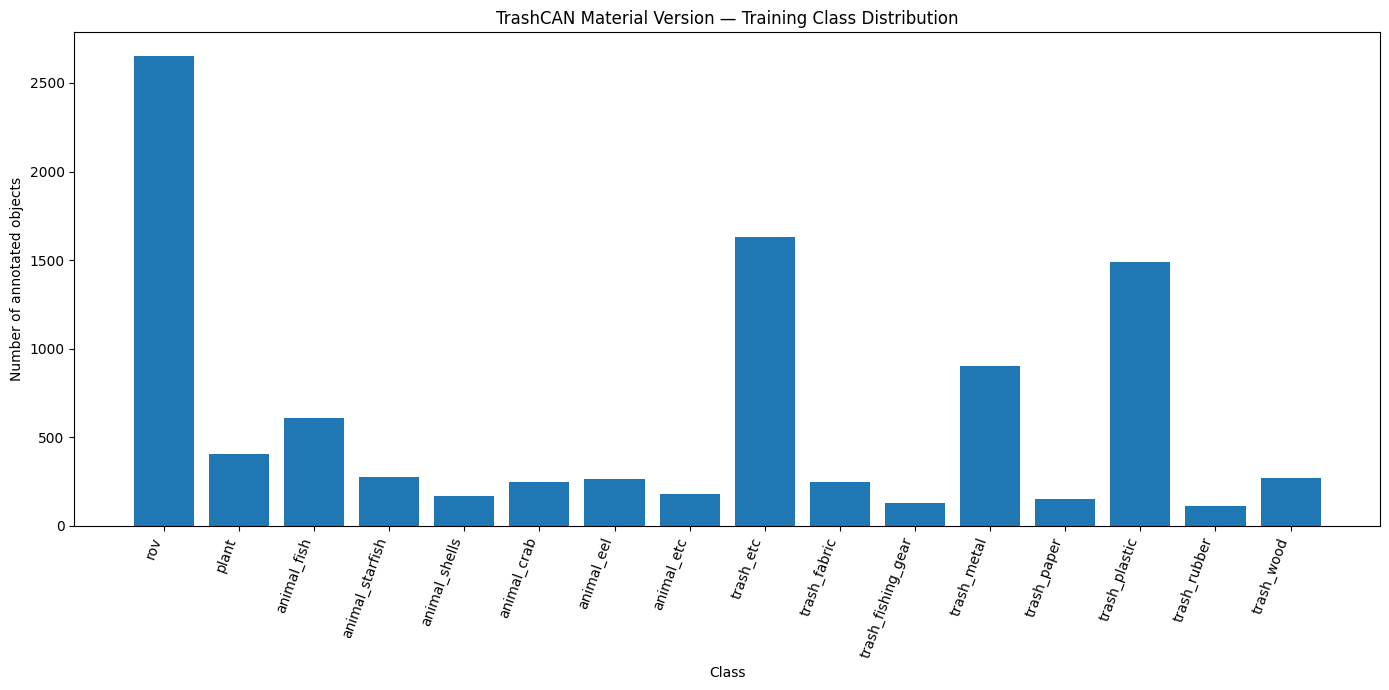

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path
import random

# Reuse train_path, train_images, train_data, category_names,
# garbage_classes and annotation_counts from the Day-2 section.

print("Visual EDA setup complete.")
print("Training images available:", len(train_images))

# Plot annotation counts for all 16 classes.
class_names = [cat['name'] for cat in categories]
class_counts = [counts.get(cat['id'], 0) for cat in categories]

plt.figure(figsize=(14, 7))
plt.bar(class_names, class_counts)
plt.xticks(rotation=70, ha='right')
plt.ylabel("Number of annotated objects")
plt.xlabel("Class")
plt.title("TrashCAN Material Version — Training Class Distribution")
plt.tight_layout()
plt.show()

## 14. Garbage-only class distribution

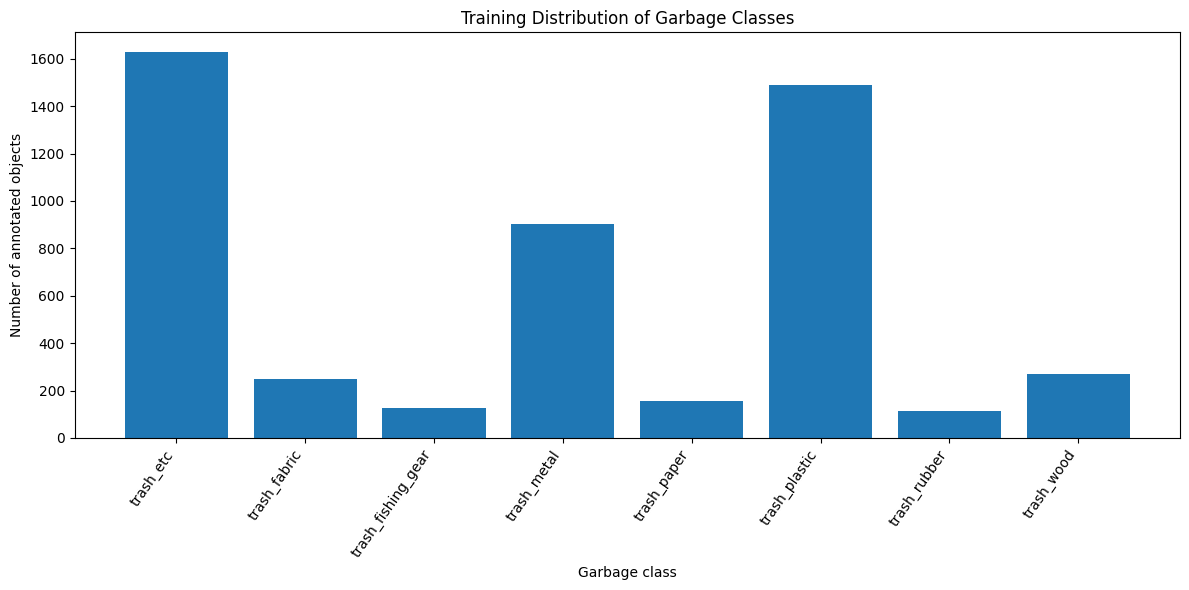

In [27]:
garbage_names = [
    name for name in class_names
    if name in garbage_classes
]

garbage_counts = []
for name in garbage_names:
    category_id = next(cat['id'] for cat in categories if cat['name'] == name)
    garbage_counts.append(counts.get(category_id, 0))

plt.figure(figsize=(12, 6))
plt.bar(garbage_names, garbage_counts)
plt.xticks(rotation=55, ha='right')
plt.ylabel("Number of annotated objects")
plt.xlabel("Garbage class")
plt.title("Training Distribution of Garbage Classes")
plt.tight_layout()
plt.show()

## 15. Quantify image brightness, contrast and blur

In [28]:
def image_quality_features(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Mean grayscale intensity: simple brightness indicator.
    brightness = float(np.mean(gray))

    # Standard deviation of grayscale intensity: simple contrast indicator.
    contrast = float(np.std(gray))

    # Variance of Laplacian: commonly used as a blur/sharpness indicator.
    blur_score = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    height, width = gray.shape
    aspect_ratio = width / height if height else np.nan

    return {
        "filename": os.path.basename(image_path),
        "width": width,
        "height": height,
        "aspect_ratio": aspect_ratio,
        "brightness": brightness,
        "contrast": contrast,
        "blur_score": blur_score
    }


quality_records = []

for filename in train_images:
    features = image_quality_features(os.path.join(train_path, filename))
    if features is not None:
        quality_records.append(features)

quality_df = pd.DataFrame(quality_records)

print("Images successfully analysed:", len(quality_df))
display(quality_df.head())


Images successfully analysed: 6008


,filename,width,height,aspect_ratio,brightness,contrast,blur_score
0,vid_000076_frame0000026.jpg,480,270,1.777778,94.835586,16.017570,2540.691775
1,vid_000253_frame0000011.jpg,480,360,1.333333,171.732622,36.656582,834.608171
2,vid_000437_frame0000037.jpg,480,360,1.333333,48.940376,38.100087,1848.744582
3,vid_000255_frame0000019.jpg,480,360,1.333333,153.342199,49.058109,805.501384
4,vid_000133_frame0000010.jpg,480,360,1.333333,52.377610,47.415120,1607.648570


## 16. Image-quality statistics

In [29]:
quality_summary = quality_df[
    ["width", "height", "aspect_ratio", "brightness", "contrast", "blur_score"]
].describe()

display(quality_summary)


,width,height,aspect_ratio,brightness,contrast,blur_score
count,6008.0,6008.000000,6008.000000,6008.000000,6008.000000,6008.000000
mean,480.0,315.059920,1.555260,94.490856,38.106700,1865.867977
std,0.0,45.003706,0.222241,34.891298,14.680317,1162.898475
min,480.0,270.000000,1.333333,10.050498,11.108543,55.449245
25%,480.0,270.000000,1.333333,71.077182,26.102376,765.369917
50%,480.0,360.000000,1.333333,90.490557,36.014482,1757.085735
75%,480.0,360.000000,1.777778,115.064397,47.576430,2829.248430
max,480.0,360.000000,1.777778,223.188328,92.135901,6425.348498


## 17. Brightness distribution

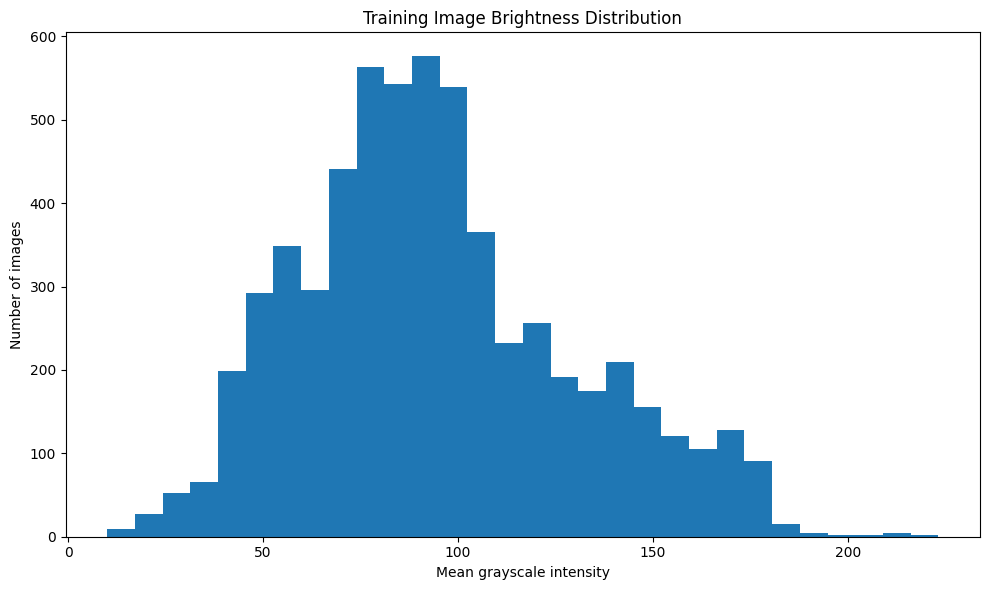

In [30]:
plt.figure(figsize=(10, 6))
plt.hist(quality_df["brightness"], bins=30)
plt.xlabel("Mean grayscale intensity")
plt.ylabel("Number of images")
plt.title("Training Image Brightness Distribution")
plt.tight_layout()
plt.show()


## 18. Contrast distribution

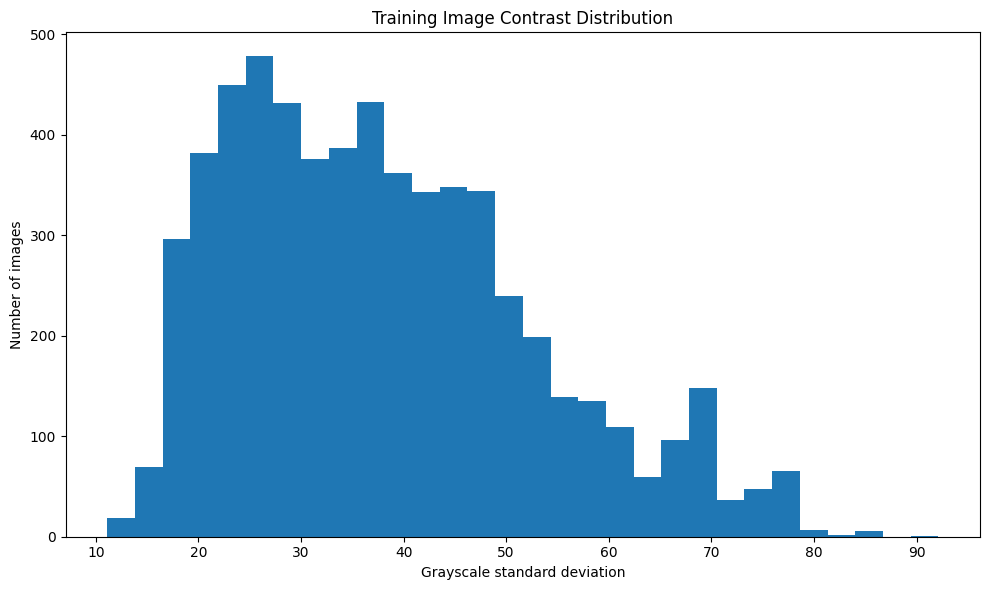

In [31]:
plt.figure(figsize=(10, 6))
plt.hist(quality_df["contrast"], bins=30)
plt.xlabel("Grayscale standard deviation")
plt.ylabel("Number of images")
plt.title("Training Image Contrast Distribution")
plt.tight_layout()
plt.show()


## 19. Blur / sharpness distribution

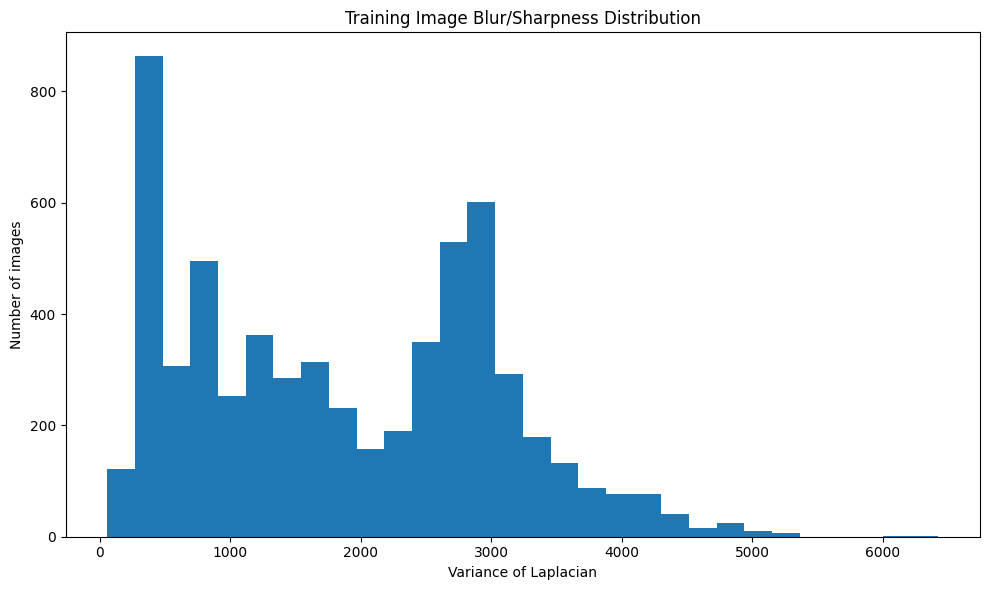

In [32]:
plt.figure(figsize=(10, 6))
plt.hist(quality_df["blur_score"], bins=30)
plt.xlabel("Variance of Laplacian")
plt.ylabel("Number of images")
plt.title("Training Image Blur/Sharpness Distribution")
plt.tight_layout()
plt.show()


## 20. Representative difficult-condition grids

The following cells identify images at the extremes of simple image-quality indicators.

**Important:** These are exploratory indicators, not ground-truth labels for "dark", "low contrast", or "blurry". Thresholds are chosen from the dataset distribution for inspection.


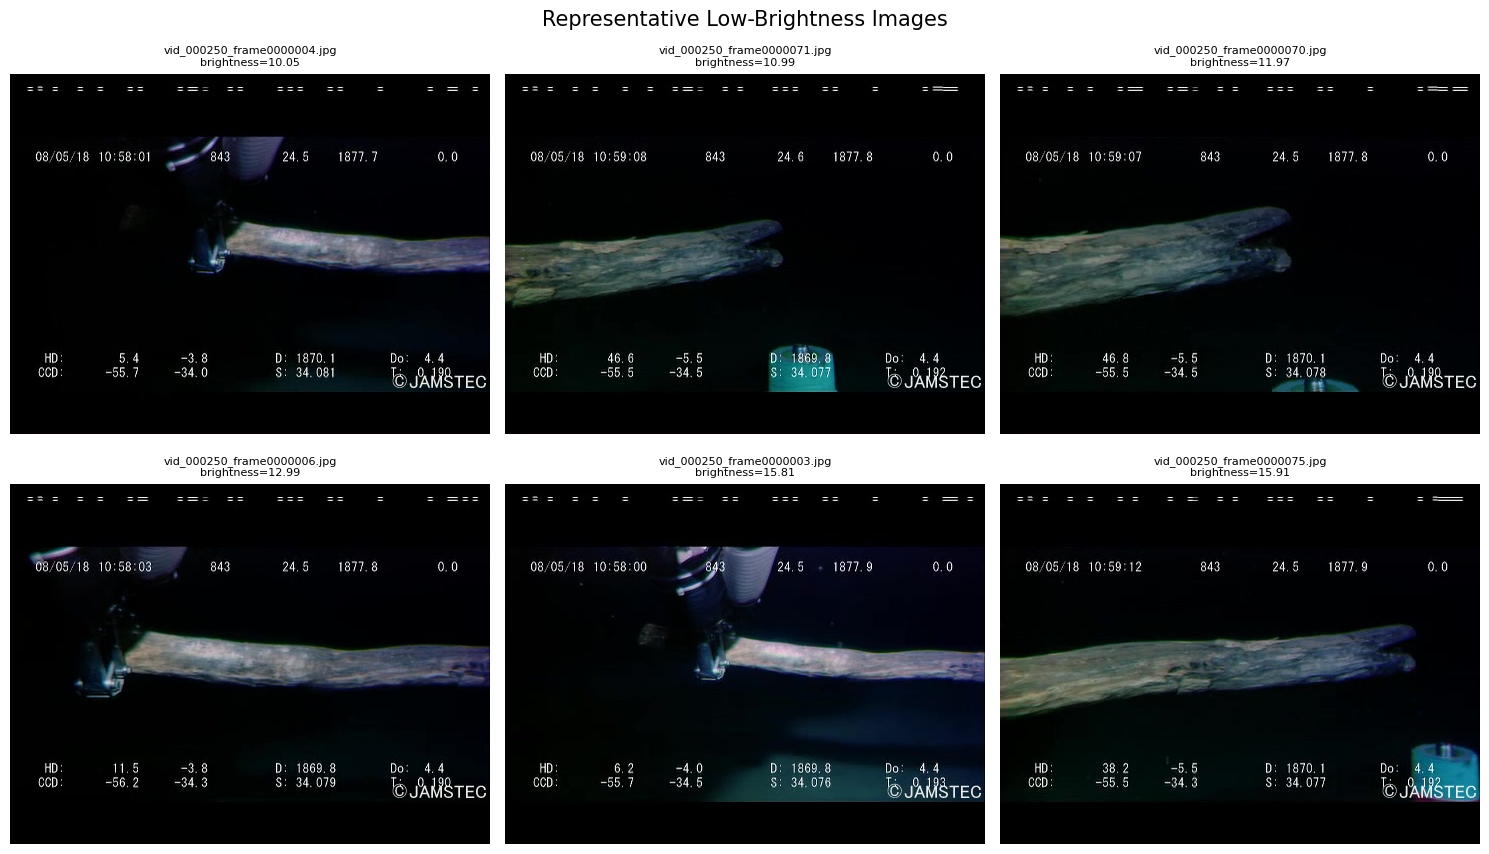

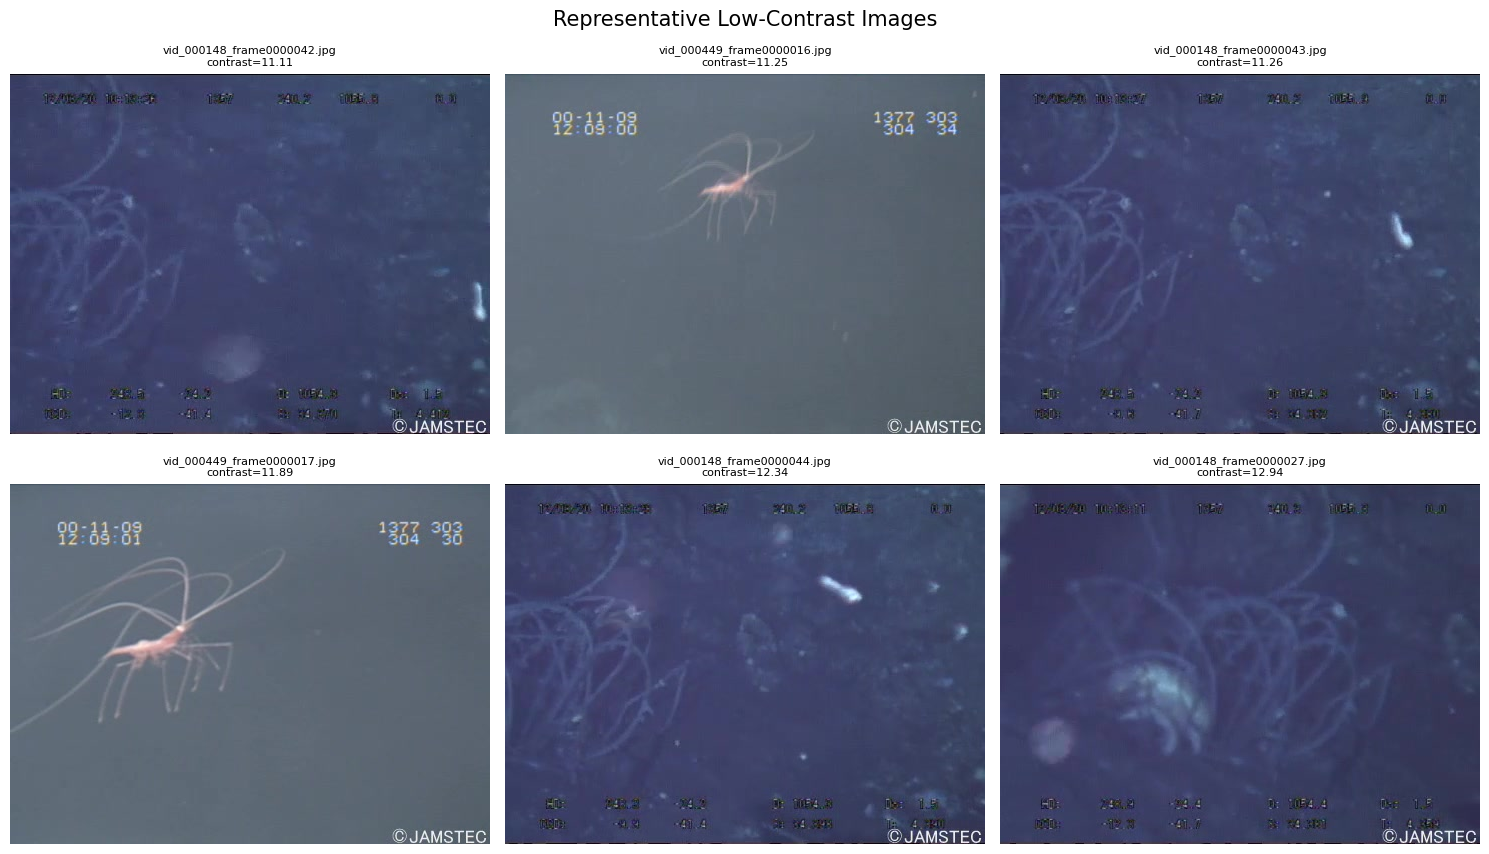

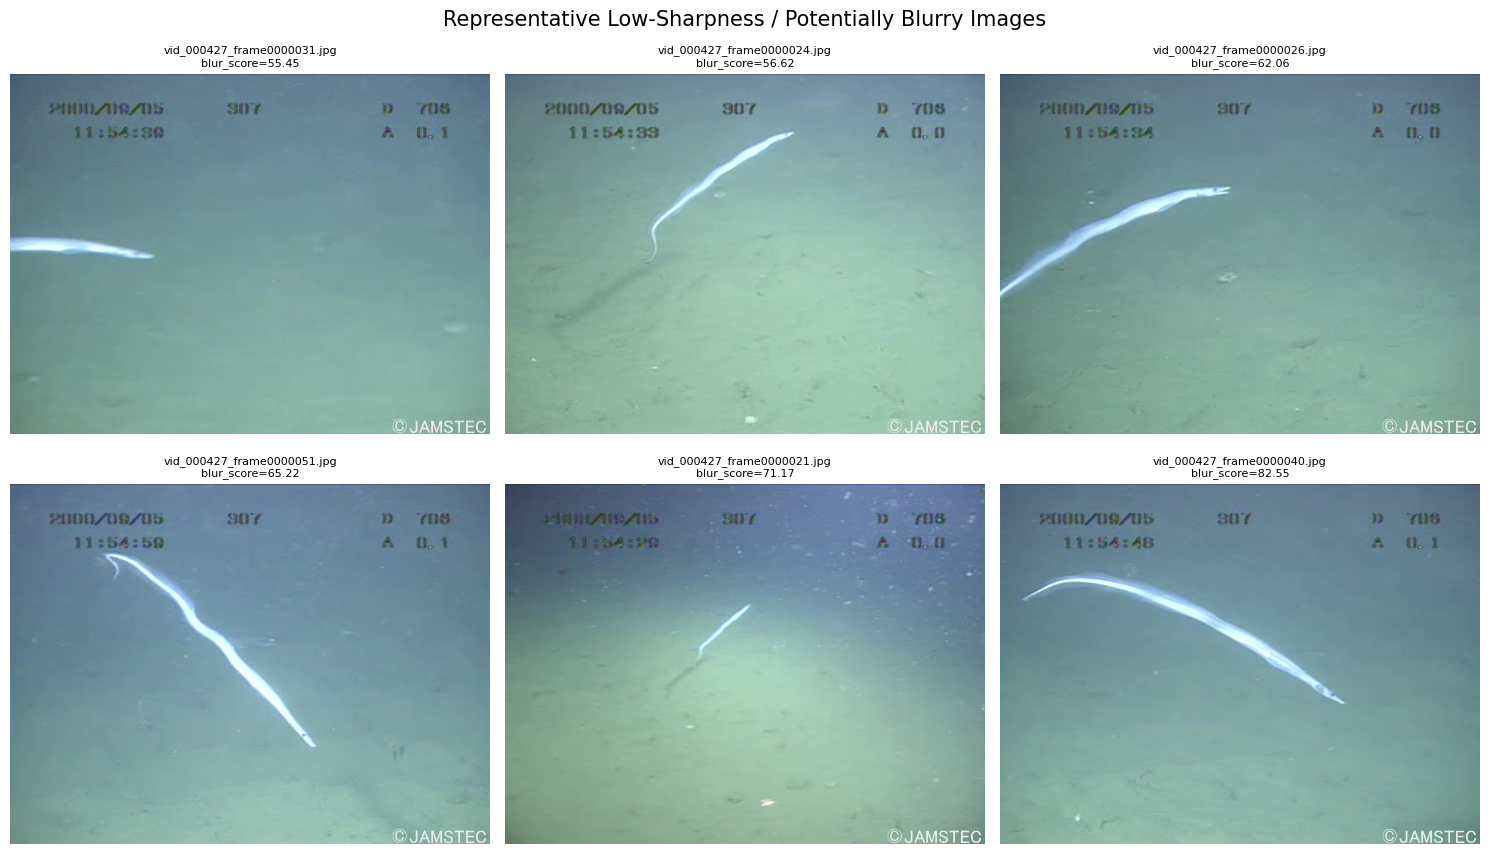

In [33]:
def show_quality_extremes(df, column, lowest=True, n=6, title=""):
    subset = df.sort_values(column, ascending=lowest).head(n)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, subset.iterrows()):
        image_path = os.path.join(train_path, row["filename"])
        img = Image.open(image_path).convert("RGB")

        ax.imshow(img)
        ax.set_title(
            f"{row['filename']}\n{column}={row[column]:.2f}",
            fontsize=8
        )
        ax.axis("off")

    for ax in axes[len(subset):]:
        ax.axis("off")

    plt.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


show_quality_extremes(
    quality_df,
    "brightness",
    lowest=True,
    title="Representative Low-Brightness Images"
)

show_quality_extremes(
    quality_df,
    "contrast",
    lowest=True,
    title="Representative Low-Contrast Images"
)

show_quality_extremes(
    quality_df,
    "blur_score",
    lowest=True,
    title="Representative Low-Sharpness / Potentially Blurry Images"
)


## 21. Quantify image-quality extremes

In [37]:
# Use dataset quantiles rather than arbitrary fixed thresholds.
brightness_low = quality_df["brightness"].quantile(0.10)
contrast_low = quality_df["contrast"].quantile(0.10)
blur_low = quality_df["blur_score"].quantile(0.10)

quality_extreme_summary = pd.DataFrame({
    "Condition": [
        "Lowest 10% brightness",
        "Lowest 10% contrast",
        "Lowest 10% blur/sharpness score"
    ],
    "Threshold": [
        brightness_low,
        contrast_low,
        blur_low
    ],
    "Number of images": [
        int((quality_df["brightness"] <= brightness_low).sum()),
        int((quality_df["contrast"] <= contrast_low).sum()),
        int((quality_df["blur_score"] <= blur_low).sum())
    ],
    "Percentage of analysed images": [
        (quality_df["brightness"] <= brightness_low).mean() * 100,
        (quality_df["contrast"] <= contrast_low).mean() * 100,
        (quality_df["blur_score"] <= blur_low).mean() * 100
    ]
})

display(quality_extreme_summary)


,Condition,Threshold,Number of images,Percentage of analysed images
0,Lowest 10% brightness,51.693022,601,10.003329
1,Lowest 10% contrast,20.615981,601,10.003329
2,Lowest 10% blur/sharpness score,371.830158,601,10.003329


## 22. Image-level object-count statistics

Images: 6008
Images with at least one annotation: 6008
Images with no annotations: 0
Average objects per image: 1.6213382157123835
Maximum objects in one image: 19


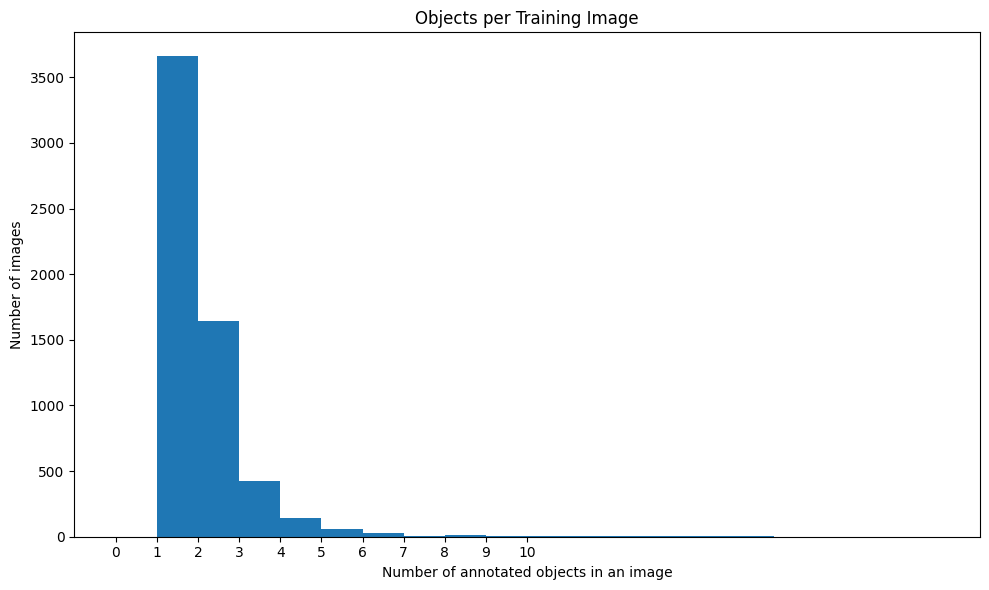

In [35]:
from collections import defaultdict

objects_per_image = defaultdict(int)

for ann in train_data["annotations"]:
    objects_per_image[ann["image_id"]] += 1

object_counts = [
    objects_per_image.get(img["id"], 0)
    for img in train_data["images"]
]

print("Images:", len(object_counts))
print("Images with at least one annotation:", sum(c > 0 for c in object_counts))
print("Images with no annotations:", sum(c == 0 for c in object_counts))
print("Average objects per image:", np.mean(object_counts))
print("Maximum objects in one image:", np.max(object_counts))

plt.figure(figsize=(10, 6))
plt.hist(object_counts, bins=range(0, max(object_counts) + 2))
plt.xlabel("Number of annotated objects in an image")
plt.ylabel("Number of images")
plt.title("Objects per Training Image")
plt.xticks(range(0, min(max(object_counts), 10) + 1))
plt.tight_layout()
plt.show()


## 23. Visual EDA observations and hypotheses

In [36]:
print("===== VISUAL EDA OBSERVATIONS =====")

print("\n1. Class distribution")
print(
    "The annotation distribution is uneven across the 16 classes. "
    "The class-distribution plots should be used to identify dominant "
    "and under-represented classes."
)

print("\n2. Image quality")
print(
    "Brightness, contrast and blur-score distributions quantify variation "
    "in image appearance. The extreme-image grids provide representative "
    "examples for manual inspection."
)

print("\n3. Underwater degradation hypotheses")
print(
    "Hypothesis: low visibility, low contrast and blur may make debris "
    "boundaries and visual features harder to distinguish."
)

print("\n4. Object density")
print(
    "The objects-per-image analysis shows whether images are mostly sparse "
    "or contain multiple annotated objects."
)

print("\n5. Important caution")
print(
    "Brightness, contrast and blur scores are proxy measurements. They do "
    "not by themselves prove that an image is difficult for the detector."
)


===== VISUAL EDA OBSERVATIONS =====

1. Class distribution
The annotation distribution is uneven across the 16 classes. The class-distribution plots should be used to identify dominant and under-represented classes.

2. Image quality
Brightness, contrast and blur-score distributions quantify variation in image appearance. The extreme-image grids provide representative examples for manual inspection.

3. Underwater degradation hypotheses
Hypothesis: low visibility, low contrast and blur may make debris boundaries and visual features harder to distinguish.

4. Object density
The objects-per-image analysis shows whether images are mostly sparse or contain multiple annotated objects.

5. Important caution
Brightness, contrast and blur scores are proxy measurements. They do not by themselves prove that an image is difficult for the detector.
